Prévision de la consommation

In [63]:
import requests
import base64
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

Lecture des données


In [64]:
fichiers = glob.glob("eCO2mix_RTE_Annuel-Definitif_*.xls")

dfs = []

for fichier in fichiers:
    df_temp = pd.read_csv(
        fichier,
        sep="\t",
        encoding="latin1",
        index_col=False,
        low_memory=False
    )
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

In [65]:
df.iloc[0]

Périmètre                                            France
Nature                                  Données définitives
Date                                             2012-01-01
Heures                                                00:00
Consommation                                        58315.0
Prévision J-1                                       58200.0
Prévision J                                         58200.0
Fioul                                                 492.0
Charbon                                                25.0
Gaz                                                  3816.0
Nucléaire                                           52697.0
Eolien                                               3588.0
Solaire                                                 0.0
Hydraulique                                          7922.0
Pompage                                             -1139.0
Bioénergies                                           719.0
Ech. physiques                          

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 429517 entries, 0 to 429516
Data columns (total 40 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Périmètre                             429517 non-null  str    
 1   Nature                                429504 non-null  str    
 2   Date                                  429504 non-null  str    
 3   Heures                                429504 non-null  str    
 4   Consommation                          214752 non-null  float64
 5   Prévision J-1                         429504 non-null  float64
 6   Prévision J                           429504 non-null  float64
 7   Fioul                                 214752 non-null  float64
 8   Charbon                               214752 non-null  float64
 9   Gaz                                   214752 non-null  float64
 10  Nucléaire                             214752 non-null  float64
 11  Eolien     

Cleaning

In [67]:
df = df[["Date", "Heures", "Consommation"]]

In [68]:
df = df[["Date", "Heures", "Consommation"]]

In [69]:
df["Consommation"] = pd.to_numeric(df["Consommation"], errors="coerce")

In [70]:
df = df.dropna(subset=["Date", "Heures"])

In [71]:
df.head(10)


,Date,Heures,Consommation
0,2012-01-01,00:00,58315.0
1,2012-01-01,00:15,NaN
2,2012-01-01,00:30,58315.0
3,2012-01-01,00:45,NaN
4,2012-01-01,01:00,56231.0
5,2012-01-01,01:15,NaN
6,2012-01-01,01:30,56075.0
7,2012-01-01,01:45,NaN
8,2012-01-01,02:00,55532.0
9,2012-01-01,02:15,NaN


In [72]:
df.columns

Index(['Date', 'Heures', 'Consommation'], dtype='str')

In [73]:
df.iloc[0]

Date            2012-01-01
Heures               00:00
Consommation       58315.0
Name: 0, dtype: object

In [74]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Heures"])

In [75]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day

In [76]:
df["is_weekend"] = df["day_of_week"] >= 5

In [77]:
X = df[["hour","day_of_week","month","day"]]
y = df["Consommation"]

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [79]:
df.head(10)

,Date,Heures,Consommation,datetime,hour,day_of_week,month,day,is_weekend
0,2012-01-01,00:00,58315.0,2012-01-01 00:00:00,0,6,1,1,True
1,2012-01-01,00:15,NaN,2012-01-01 00:15:00,0,6,1,1,True
2,2012-01-01,00:30,58315.0,2012-01-01 00:30:00,0,6,1,1,True
3,2012-01-01,00:45,NaN,2012-01-01 00:45:00,0,6,1,1,True
4,2012-01-01,01:00,56231.0,2012-01-01 01:00:00,1,6,1,1,True
5,2012-01-01,01:15,NaN,2012-01-01 01:15:00,1,6,1,1,True
6,2012-01-01,01:30,56075.0,2012-01-01 01:30:00,1,6,1,1,True
7,2012-01-01,01:45,NaN,2012-01-01 01:45:00,1,6,1,1,True
8,2012-01-01,02:00,55532.0,2012-01-01 02:00:00,2,6,1,1,True
9,2012-01-01,02:15,NaN,2012-01-01 02:15:00,2,6,1,1,True


In [80]:
df["Consommation"].isnull().sum()

np.int64(214752)

In [81]:
df.head(214752)

,Date,Heures,Consommation,datetime,hour,day_of_week,month,day,is_weekend
0,2012-01-01,00:00,58315.0,2012-01-01 00:00:00,0,6,1,1,True
1,2012-01-01,00:15,NaN,2012-01-01 00:15:00,0,6,1,1,True
2,2012-01-01,00:30,58315.0,2012-01-01 00:30:00,0,6,1,1,True
3,2012-01-01,00:45,NaN,2012-01-01 00:45:00,0,6,1,1,True
4,2012-01-01,01:00,56231.0,2012-01-01 01:00:00,1,6,1,1,True
...,...,...,...,...,...,...,...,...,...
214753,2018-02-14,22:45,NaN,2018-02-14 22:45:00,22,2,2,14,False
214754,2018-02-14,23:00,75635.0,2018-02-14 23:00:00,23,2,2,14,False
214755,2018-02-14,23:15,NaN,2018-02-14 23:15:00,23,2,2,14,False
214756,2018-02-14,23:30,74396.0,2018-02-14 23:30:00,23,2,2,14,False


In [82]:
print("Avant :", len(df))
df = df.dropna(subset=["Consommation"])
print("Après :", len(df))

Avant : 429504
Après : 214752


In [83]:
df.shape

(214752, 9)

In [84]:
df.head(100)

,Date,Heures,Consommation,datetime,hour,day_of_week,month,day,is_weekend
0,2012-01-01,00:00,58315.0,2012-01-01 00:00:00,0,6,1,1,True
2,2012-01-01,00:30,58315.0,2012-01-01 00:30:00,0,6,1,1,True
4,2012-01-01,01:00,56231.0,2012-01-01 01:00:00,1,6,1,1,True
6,2012-01-01,01:30,56075.0,2012-01-01 01:30:00,1,6,1,1,True
8,2012-01-01,02:00,55532.0,2012-01-01 02:00:00,2,6,1,1,True
...,...,...,...,...,...,...,...,...,...
190,2012-01-02,23:30,64902.0,2012-01-02 23:30:00,23,0,1,2,False
192,2012-01-03,00:00,64600.0,2012-01-03 00:00:00,0,1,1,3,False
194,2012-01-03,00:30,63033.0,2012-01-03 00:30:00,0,1,1,3,False
196,2012-01-03,01:00,60533.0,2012-01-03 01:00:00,1,1,1,3,False


In [85]:
df["Consommation"].isna().sum()

np.int64(0)

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [87]:
X = df[["hour", "day_of_week", "month", "day"]]
y = df["Consommation"]

In [88]:
df.head(10)

,Date,Heures,Consommation,datetime,hour,day_of_week,month,day,is_weekend
0,2012-01-01,00:00,58315.0,2012-01-01 00:00:00,0,6,1,1,True
2,2012-01-01,00:30,58315.0,2012-01-01 00:30:00,0,6,1,1,True
4,2012-01-01,01:00,56231.0,2012-01-01 01:00:00,1,6,1,1,True
6,2012-01-01,01:30,56075.0,2012-01-01 01:30:00,1,6,1,1,True
8,2012-01-01,02:00,55532.0,2012-01-01 02:00:00,2,6,1,1,True
10,2012-01-01,02:30,54911.0,2012-01-01 02:30:00,2,6,1,1,True
12,2012-01-01,03:00,52496.0,2012-01-01 03:00:00,3,6,1,1,True
14,2012-01-01,03:30,50664.0,2012-01-01 03:30:00,3,6,1,1,True
16,2012-01-01,04:00,49161.0,2012-01-01 04:00:00,4,6,1,1,True
18,2012-01-01,04:30,47596.0,2012-01-01 04:30:00,4,6,1,1,True


In [89]:
y_train.isna().sum()

np.int64(171698)

In [90]:
df = df.dropna(subset=["Consommation"]).reset_index(drop=True)

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [92]:
X = df[["hour", "day_of_week", "month", "day"]]
y = df["Consommation"]

In [93]:
y_train.isna().sum()

np.int64(0)

In [94]:
print("NaN dans y :", y_train.isna().sum())
print("NaN total dans X :", X_train.isna().sum().sum())

print("\nColonnes avec NaN :")
print(X_train.isna().sum().sort_values(ascending=False).head(10))

NaN dans y : 0
NaN total dans X : 0

Colonnes avec NaN :
hour           0
day_of_week    0
month          0
day            0
dtype: int64


In [95]:
y.isna().sum()

np.int64(0)

In [96]:
X.loc[y.isna()]

,hour,day_of_week,month,day


In [97]:
df.head(10)

,Date,Heures,Consommation,datetime,hour,day_of_week,month,day,is_weekend
0,2012-01-01,00:00,58315.0,2012-01-01 00:00:00,0,6,1,1,True
1,2012-01-01,00:30,58315.0,2012-01-01 00:30:00,0,6,1,1,True
2,2012-01-01,01:00,56231.0,2012-01-01 01:00:00,1,6,1,1,True
3,2012-01-01,01:30,56075.0,2012-01-01 01:30:00,1,6,1,1,True
4,2012-01-01,02:00,55532.0,2012-01-01 02:00:00,2,6,1,1,True
5,2012-01-01,02:30,54911.0,2012-01-01 02:30:00,2,6,1,1,True
6,2012-01-01,03:00,52496.0,2012-01-01 03:00:00,3,6,1,1,True
7,2012-01-01,03:30,50664.0,2012-01-01 03:30:00,3,6,1,1,True
8,2012-01-01,04:00,49161.0,2012-01-01 04:00:00,4,6,1,1,True
9,2012-01-01,04:30,47596.0,2012-01-01 04:30:00,4,6,1,1,True


In [98]:
df["Consommation"] = pd.to_numeric(df["Consommation"], errors="coerce")

In [99]:
df = df.dropna(subset=["Consommation"])

In [100]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

MemoryError: could not allocate 4194304 bytes

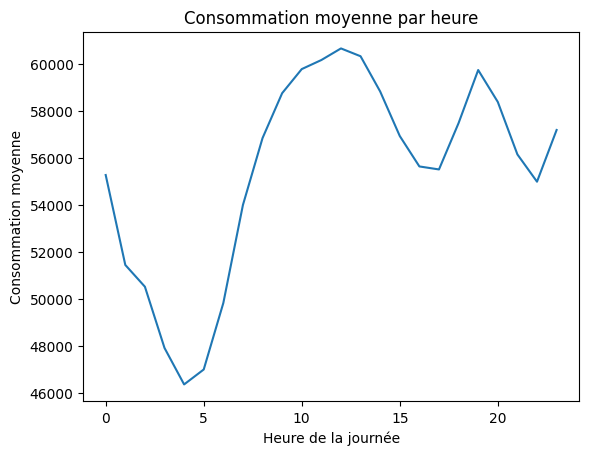

In [ ]:
import matplotlib.pyplot as plt

conso_par_heure = df.groupby("hour")["Consommation"].mean()

plt.figure()
conso_par_heure.plot()
plt.xlabel("Heure de la journée")
plt.ylabel("Consommation moyenne")
plt.title("Consommation moyenne par heure")
plt.show()

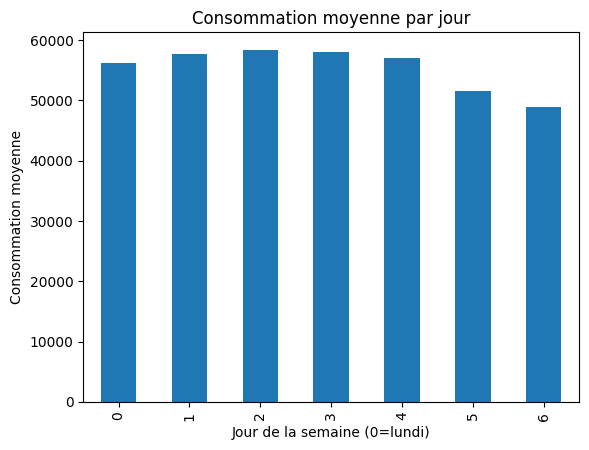

In [ ]:
conso_par_jour = df.groupby("day_of_week")["Consommation"].mean()

plt.figure()
conso_par_jour.plot(kind="bar")
plt.xlabel("Jour de la semaine (0=lundi)")
plt.ylabel("Consommation moyenne")
plt.title("Consommation moyenne par jour")
plt.show()

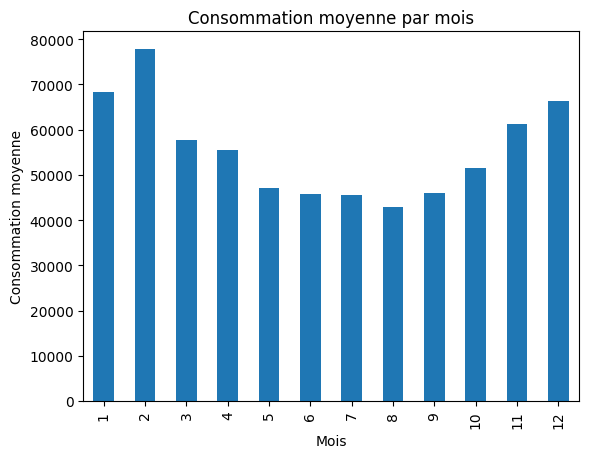

In [ ]:
conso_par_mois = df.groupby("month")["Consommation"].mean()

plt.figure()
conso_par_mois.plot(kind="bar")
plt.xlabel("Mois")
plt.ylabel("Consommation moyenne")
plt.title("Consommation moyenne par mois")
plt.show()

In [ ]:
import pandas as pd

nouvelle_donnee = pd.DataFrame({
    "hour":[18],
    "day_of_week":[1],
    "month":[1],
    "day":[10]
})

prediction = model.predict(nouvelle_donnee)

print("Consommation prédite:", prediction)

Consommation prédite: [75476.21183333]
